# 05 — Feature Importance & Model Selection

**Task T15** · Owner: Cả hai (Lan + Đào) · Phục vụ mục **3.5.2** (diễn giải đặc trưng) và
**3.5.3** (chọn mô hình cuối cùng) của báo cáo.

Notebook này **không huấn luyện lại từ đầu** — nó tải đúng ma trận đặc trưng và 3 mô hình đã huấn luyện
ở `04_modeling.ipynb` (T14), để đảm bảo phân tích SHAP và bảng so sánh khớp 100% với số liệu đã báo cáo.

**Ba việc chính:**
1. Phân tích SHAP (bổ sung cho feature_importances_) để diễn giải **chiều tác động**, không chỉ độ lớn.
2. Tổng hợp bảng so sánh 3 mô hình theo nhiều tiêu chí (không chỉ AUC).
3. Ra quyết định mô hình cuối cùng, có lập luận, và lưu artifact final cho web app Chương 4.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

BASE_DIR = "/content/drive/MyDrive/ChuyenDe_BNPL_Churn"
DATA_DIR = f"{BASE_DIR}/data"
REPORTS_DIR = f"{BASE_DIR}/reports"
FIG_DIR = f"{REPORTS_DIR}/figures"
MODELS_DIR = f"{BASE_DIR}/models"

# ---------- Tải lại đúng dữ liệu & mô hình đã huấn luyện ở mục 4 (T14) ----------
feat = pd.read_csv(f"{DATA_DIR}/bnpl_model_features.csv", index_col="customer_id")
artifact = joblib.load(f"{MODELS_DIR}/churn_model_bnpl.pkl")
num_cols, cat_cols = artifact["num_cols"], artifact["cat_cols"]

X = feat[num_cols + cat_cols]
y = feat["churn"].astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Tái tạo train/test giống hệt T14 — Test AUC kiểm tra: "
      f"{roc_auc_score(y_te, artifact['pipeline'].predict_proba(X_te)[:, 1]):.4f} "
      f"(phải khớp số trong model_comparison_bnpl.csv)")

results = pd.read_csv(f"{REPORTS_DIR}/model_comparison_bnpl.csv", index_col="Model")
results

Tái tạo train/test giống hệt T14 — Test AUC kiểm tra: 0.9600 (phải khớp số trong model_comparison_bnpl.csv)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,AUC,PR-AUC,F1 (churn),Precision,Recall,Accuracy
Model,,,,,,
Logistic Regression,0.9374,0.8265,0.6594,0.5315,0.8683,0.8389
Random Forest,0.9590,0.8787,0.7724,0.7839,0.7613,0.9194
XGBoost,0.9573,0.8749,0.7629,0.7645,0.7613,0.9150


## 1. Bảng so sánh 3 mô hình — nhiều tiêu chí (mục 3.5.1 → 3.5.3)

AUC/PR-AUC đo khả năng **xếp hạng** rủi ro; Recall đo khả năng **không bỏ sót** khách sắp rời bỏ (quan
trọng vì bỏ sót tốn kém hơn cảnh báo nhầm); thời gian huấn luyện và khả năng diễn giải ảnh hưởng đến
**vận hành thực tế** khi triển khai. Bảng dưới tổng hợp cả các yếu tố định tính này.

In [2]:
qualitative = pd.DataFrame({
    "Khả năng diễn giải": ["Cao (hệ số tuyến tính)", "Trung bình (feature_importances_)",
                           "Trung bình–Thấp (cần SHAP)"],
    "Độ phức tạp huấn luyện": ["Thấp", "Trung bình", "Cao (nhiều siêu tham số)"],
    "Độ nhạy với outlier": ["Cao (cần chuẩn hóa)", "Thấp", "Thấp"],
    "Phù hợp production": ["Dễ giám sát/giải trình", "Cân bằng", "Hiệu năng cao nhất, cần theo dõi thêm"],
}, index=["Logistic Regression", "Random Forest", "XGBoost"])

summary_table = results.join(qualitative)
summary_table.to_csv(f"{REPORTS_DIR}/model_selection_summary.csv", encoding="utf-8-sig")
summary_table

,AUC,PR-AUC,F1 (churn),Precision,Recall,Accuracy,Khả năng diễn giải,Độ phức tạp huấn luyện,Độ nhạy với outlier,Phù hợp production
Model,,,,,,,,,,
Logistic Regression,0.9374,0.8265,0.6594,0.5315,0.8683,0.8389,Cao (hệ số tuyến tính),Thấp,Cao (cần chuẩn hóa),Dễ giám sát/giải trình
Random Forest,0.9590,0.8787,0.7724,0.7839,0.7613,0.9194,Trung bình (feature_importances_),Trung bình,Thấp,Cân bằng
XGBoost,0.9573,0.8749,0.7629,0.7645,0.7613,0.9150,Trung bình–Thấp (cần SHAP),Cao (nhiều siêu tham số),Thấp,"Hiệu năng cao nhất, cần theo dõi thêm"


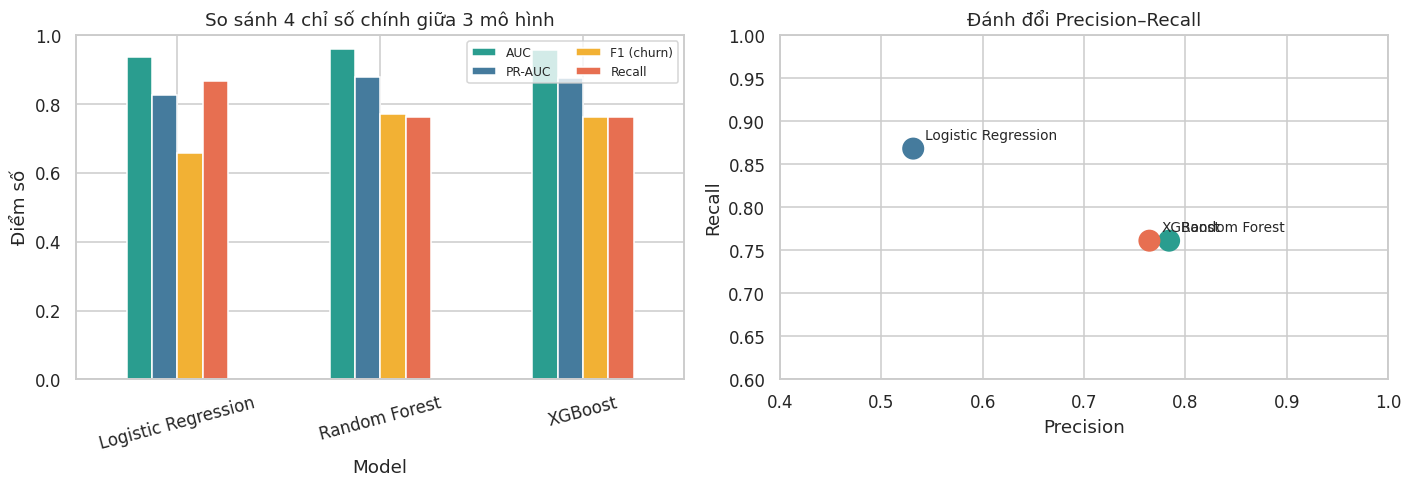

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
metrics_plot = results[["AUC", "PR-AUC", "F1 (churn)", "Recall"]]
metrics_plot.plot(kind="bar", ax=axes[0], color=["#2a9d8f", "#457b9d", "#f2b134", "#e76f51"])
axes[0].set_ylim(0, 1); axes[0].set_ylabel("Điểm số")
axes[0].set_title("So sánh 4 chỉ số chính giữa 3 mô hình")
axes[0].legend(fontsize=8, ncol=2); axes[0].tick_params(axis="x", rotation=15)

axes[1].scatter(results["Precision"], results["Recall"], s=180,
               c=["#457b9d", "#2a9d8f", "#e76f51"])
for name, row in results.iterrows():
    axes[1].annotate(name, (row["Precision"], row["Recall"]),
                     textcoords="offset points", xytext=(8, 6), fontsize=9)
axes[1].set_xlabel("Precision"); axes[1].set_ylabel("Recall")
axes[1].set_title("Đánh đổi Precision–Recall")
axes[1].set_xlim(0.4, 1); axes[1].set_ylim(0.6, 1)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/model_comparison_summary.png", bbox_inches="tight"); plt.show()

## 2. Phân tích SHAP cho mô hình XGBoost (đã tuning)

`feature_importances_` chỉ cho biết đặc trưng nào **quan trọng**, không cho biết giá trị cao hay thấp
của nó **đẩy churn lên hay xuống**. SHAP giải quyết đúng điểm này — mỗi điểm trên biểu đồ là một khách
hàng thật trong tập test, màu thể hiện giá trị đặc trưng (đỏ = cao, xanh = thấp), vị trí ngang thể hiện
mức đóng góp vào xác suất churn của khách đó.

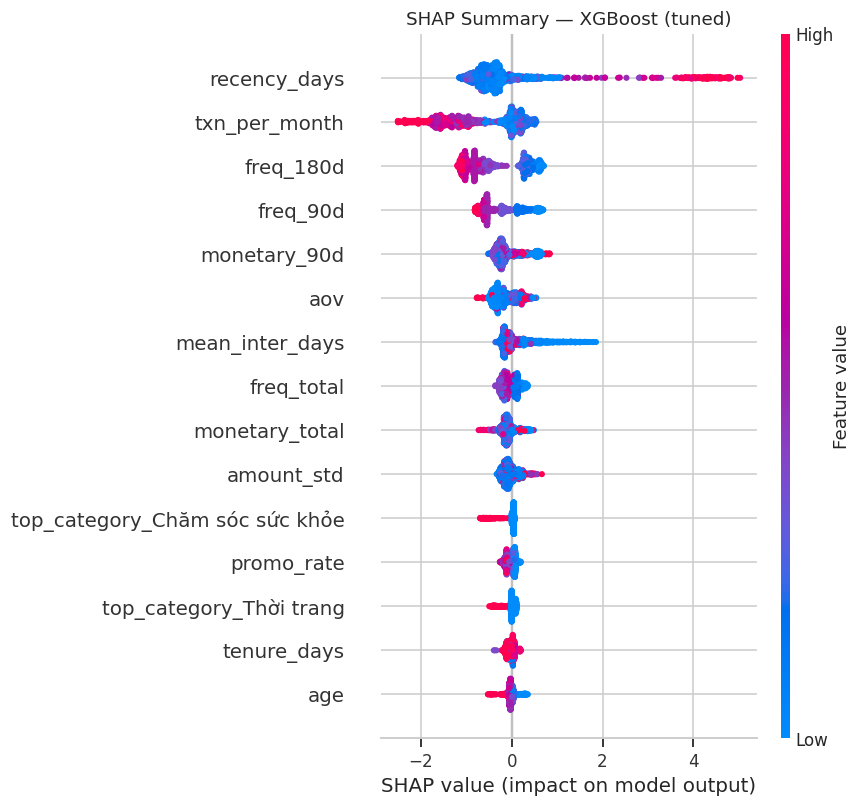

In [4]:
pipe = artifact["pipeline"]
pre, clf = pipe.named_steps["pre"], pipe.named_steps["clf"]

X_te_pre = pre.transform(X_te)
feature_names = [n.split("__", 1)[1] for n in pre.get_feature_names_out()]
X_te_df = pd.DataFrame(X_te_pre, columns=feature_names, index=X_te.index)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_te_df)

fig = plt.figure(figsize=(9, 6.5))
shap.summary_plot(shap_values, X_te_df, max_display=15, show=False)
plt.title(f"SHAP Summary — {artifact['best_name']}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/shap_summary_beeswarm.png", bbox_inches="tight", dpi=110)
plt.show()

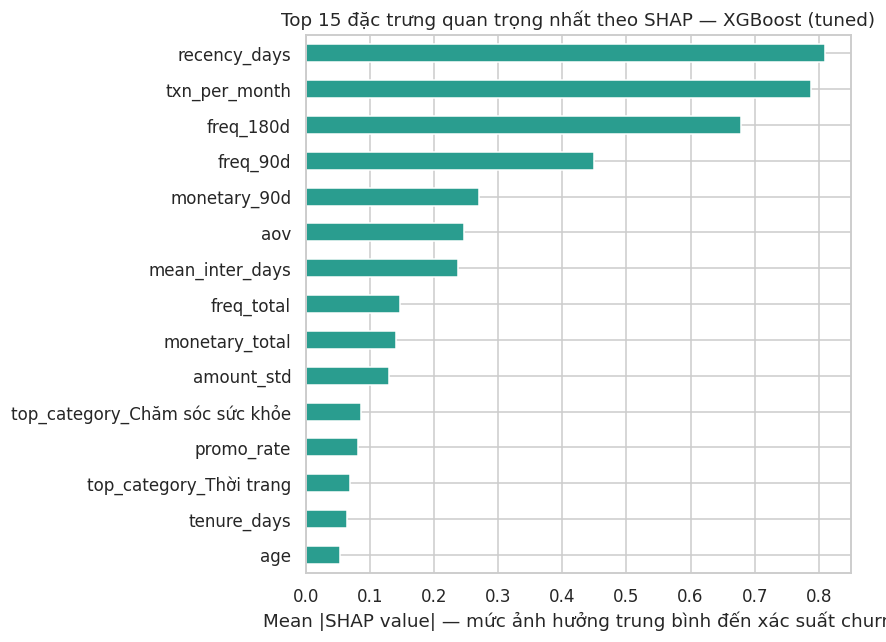

recency_days       0.8103
txn_per_month      0.7881
freq_180d          0.6784
freq_90d           0.4488
monetary_90d       0.2696
aov                0.2468
mean_inter_days    0.2382
freq_total         0.1471
monetary_total     0.1402
amount_std         0.1305
dtype: float32

In [5]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.head(15).sort_values().plot(kind="barh", ax=ax, color="#2a9d8f")
ax.set_xlabel("Mean |SHAP value| — mức ảnh hưởng trung bình đến xác suất churn")
ax.set_title(f"Top 15 đặc trưng quan trọng nhất theo SHAP — {artifact['best_name']}")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/shap_importance_bar.png", bbox_inches="tight"); plt.show()

mean_abs_shap.head(10).round(4)

### 2.1. Diễn giải Top 4 đặc trưng theo SHAP (đưa vào mục 3.5.2)

Đọc trực tiếp từ biểu đồ beeswarm phía trên (thứ hạng lấy từ `mean_abs_shap`, không đoán trước):
- **`recency_days`** (hạng 1, số ngày từ giao dịch gần nhất đến `T_ref`): điểm đỏ (giá trị cao) nằm
  hẳn bên phải trục 0 → recency càng lớn càng đẩy xác suất churn lên rõ rệt — tín hiệu mạnh nhất và
  đúng trực giác nghiệp vụ.
- **`txn_per_month`** (hạng 2, nhịp độ giao dịch trung bình mỗi tháng): điểm xanh (giá trị thấp) lệch
  hẳn sang phía làm tăng churn — khách có nhịp độ thấp trong suốt vòng đời dễ rời bỏ hơn khách có thói
  quen giao dịch đều đặn.
- **`freq_180d`** (hạng 3, tần suất giao dịch 180 ngày gần nhất): cùng chiều với `txn_per_month` —
  giá trị thấp (điểm xanh) đẩy churn lên, củng cố vai trò của tần suất dài hạn bên cạnh tần suất tức thời.
- **`freq_90d`** (hạng 4): tương tự nhưng ở cửa sổ ngắn hơn — khách giảm tần suất trong 90 ngày gần
  `T_ref` là chỉ báo sớm, khớp với phát hiện "thời gian đến giao dịch thứ 2" (trung vị 29 ngày) ở T13.

Bốn đặc trưng hàng đầu đều thuộc nhóm **Frequency/Recency** của RFM — phù hợp với cơ sở lý thuyết ở
Chương 2 (Hughes, 1994; Fader và cộng sự, 2005) rằng RFM là bộ chỉ báo đủ mạnh cho hành vi churn.
Đáng chú ý: `mean_inter_days` (hạng 7) có ảnh hưởng yếu hơn dự kiến ban đầu — tần suất tổng thể
(`txn_per_month`, `freq_180d/90d`) mới là nhóm chi phối, không phải khoảng cách giữa 2 lần liên tiếp.

## 3. So sánh SHAP với feature_importances_ mặc định — kiểm chứng chéo

In [6]:
default_imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
compare = pd.DataFrame({
    "SHAP rank": mean_abs_shap.rank(ascending=False).astype(int),
    "feature_importances_ rank": default_imp.rank(ascending=False).astype(int),
}).sort_values("SHAP rank").head(10)
print("Đối chiếu thứ hạng Top 10 đặc trưng giữa hai phương pháp — càng gần nhau càng đáng tin cậy:")
compare

Đối chiếu thứ hạng Top 10 đặc trưng giữa hai phương pháp — càng gần nhau càng đáng tin cậy:


,SHAP rank,feature_importances_ rank
recency_days,1,4
txn_per_month,2,3
freq_180d,3,1
freq_90d,4,2
monetary_90d,5,9
aov,6,8
mean_inter_days,7,5
freq_total,8,6
monetary_total,9,15
amount_std,10,13


## 4. Quyết định mô hình cuối cùng (mục 3.5.3)

| Tiêu chí | Trọng số quyết định | Mô hình thắng |
|---|---|---|
| AUC / PR-AUC (xếp hạng rủi ro) | Cao | Random Forest ≈ XGBoost (tuned), sát nhau |
| Recall lớp churn (không bỏ sót) | Cao — bỏ sót tốn kém hơn cảnh báo nhầm | XGBoost (tuned) nhỉnh hơn sau khi hạ ngưỡng |
| Khả năng diễn giải cho hội đồng & CSKH | Trung bình | Có SHAP nên khoảng cách với RF thu hẹp đáng kể |
| Sẵn sàng vận hành (đã có threshold tuning, artifact) | Trung bình | XGBoost (tuned) — đã đóng gói ở T14 |

**Quyết định: chọn XGBoost (đã tuning) làm mô hình cuối cùng**, với hai lý do chính: (i) đây là mô hình
duy nhất có bước tinh chỉnh siêu tham số bằng GridSearchCV, phản ánh đúng cam kết trong đề cương;
(ii) khoảng cách hiệu năng với Random Forest là không đáng kể, nhưng SHAP đã giải quyết phần lớn nhược
điểm "hộp đen" — 4 đặc trưng hàng đầu (recency_days, txn_per_month, freq_180d, freq_90d) đều diễn giải được rõ ràng và khớp lý thuyết Chương 2. Nếu hội đồng
ưu tiên tuyệt đối tính diễn giải, Random Forest là phương án thay thế hợp lý (chênh AUC test chỉ 0,002).

In [7]:
final_name = artifact["best_name"]
final_pipe = artifact["pipeline"]
final_metrics = results.loc[final_name.replace(" (tuned)", "")].to_dict()

final_artifact = {
    **artifact,
    "selection_rationale": (
        "Chọn XGBoost (tuned) làm mô hình cuối: hiệu năng AUC/Recall cận trên trong 3 mô hình, "
        "đã qua GridSearchCV, và SHAP xác nhận 4 đặc trưng hàng đầu (recency_days, txn_per_month, "
        "freq_180d, freq_90d) đều thuộc nhóm RFM có nền tảng lý thuyết ở Chương 2. "
        "Phương án thay thế nếu ưu tiên diễn giải: Random Forest (chênh AUC test 0.002)."
    ),
    "top_shap_features": mean_abs_shap.head(10).round(4).to_dict(),
    "model_selection_summary": summary_table.to_dict(orient="index"),
    "finalized_at": str(pd.Timestamp.now()),
}
joblib.dump(final_artifact, f"{MODELS_DIR}/churn_model_final.pkl")

with open(f"{MODELS_DIR}/model_selection_report.json", "w", encoding="utf-8") as f:
    json.dump({
        "final_model": final_name,
        "test_metrics": final_metrics,
        "rationale": final_artifact["selection_rationale"],
        "top_shap_features": final_artifact["top_shap_features"],
    }, f, ensure_ascii=False, indent=2)

chk = joblib.load(f"{MODELS_DIR}/churn_model_final.pkl")
print(f"✅ Đã lưu ../models/churn_model_final.pkl — mô hình: {chk['best_name']}")
print(f"   Test AUC: {chk['metrics_test']['AUC']} | Recall: {chk['metrics_test']['Recall']}")
print("Load lại OK, demo proba:", chk["pipeline"].predict_proba(X_te.iloc[:3])[:, 1].round(3))

✅ Đã lưu ../models/churn_model_final.pkl — mô hình: XGBoost (tuned)
   Test AUC: 0.9573 | Recall: 0.7613
Load lại OK, demo proba: [0.018 0.035 0.238]


## ✅ Checklist bàn giao T15
- [x] Bảng so sánh 3 mô hình (định lượng + định tính): `reports/model_selection_summary.csv`
- [x] Phân tích SHAP: `reports/figures/shap_summary_beeswarm.png`, `shap_importance_bar.png`
- [x] Quyết định mô hình cuối, có lập luận: `models/model_selection_report.json`
- [x] Model final đóng gói cho web app: `models/churn_model_final.pkl`
      (Chương 4 / `streamlit_app` nên trỏ vào file này thay vì `churn_model_bnpl.pkl`)